# ruppik2025 — Ruppik et al. (2025) Less is More (local ID)

Local 2NN intrinsic dimension, **per layer**, of a trained network — a stand-in for the paper's language-model layers.


## What the paper does

Estimates the **local intrinsic dimension (LID)** of a model's hidden representations with a **two-nearest-neighbour (2NN)** estimator applied *locally* (per neighbourhood), then tracks how LID changes across layers and training.

**Methodology:** per-layer representations → local 2NN ID estimate → mean LID per layer.

**Expected result:** in the paper, mean LID is an early-warning signal for **overfitting** and **grokking** (Figs. 2, 7).  Here, on a CNN, the robust qualitative effect is that LID **shrinks with depth** — early layers hold high-dimensional representations, later layers compress toward the low-dimensional class structure.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/2506.01034](https://arxiv.org/abs/2506.01034)
- **Venue:** NeurIPS 2025
- **Datasets used:** MultiWOZ, GoEmotions, modular-arithmetic grokking.
- **Models used:** BERT, RoBERTa, small transformers.  Here: a small CNN on CIFAR-10 as a portable stand-in.
- **Headline result to aim for:** Mean local intrinsic dimension predicts overfitting and grokking phase transitions (Figs. 2 and 7).
- **Reference code:** [https://github.com/aidos-lab/Topo_LLM_public](https://github.com/aidos-lab/Topo_LLM_public)
- **Other notes:** Companion repo: https://github.com/aidos-lab/grokking-via-lid

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook runs on real activations.**  A small CNN is trained briefly on the local CIFAR-10 cache; we estimate local ID at each layer.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, accuracy, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Train a small CNN


In [2]:
X_tr, y_tr = load_cifar10('train', n_samples=2000)
X_te, y_te = load_cifar10('test',  n_samples=400)
model = CNN_FCN(in_channels=3, num_classes=10, width=16, feat=64, hidden=32)
train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=5,
              aspects=['activations'], device=DEVICE, verbose=False)
print('trained.')


paper_reproduce/_torch_setup.py:525: UserWarning: Model 'Sequential' has both fully-connected (linear / SoRO) and conv layers. Defaulting to the fully-connected layers. Pass layer_selection='all_linear', 'all_conv', 'soro', 'linear_and_conv', 'all', or a list of names/indices to suppress this warning.
  extractor = TrainingExtractor(


trained.


## 2. Local intrinsic dimension per layer — model-first

The preset does the work: `fit_model` extracts each layer's activations and runs the local-ID estimator per layer — no manual extraction.


In [3]:
pipe = TDAPipeline.from_paper("ruppik2025")
result = pipe.fit_model(model, X_te[:200],
                        representation='activations',
                        layer_selection='linear_and_conv')
lid = result.dimension_result['id_estimates']
for i, d in enumerate(lid):
    print(f'  layer {i}: local ID = {d:.2f}')


  layer 0: local ID = 19.04
  layer 1: local ID = 12.15
  layer 2: local ID = 2.75
  layer 3: local ID = 2.51


## 3. Local ID vs depth


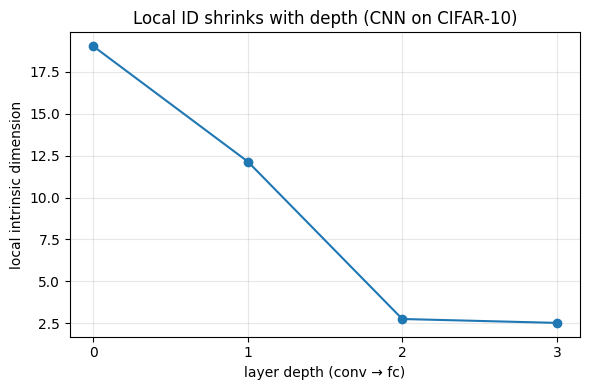

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(range(len(lid)), lid, 'o-')
plt.xlabel('layer depth (conv → fc)'); plt.ylabel('local intrinsic dimension')
plt.xticks(range(len(lid))); plt.grid(alpha=0.3)
plt.title('Local ID shrinks with depth (CNN on CIFAR-10)')
plt.tight_layout(); plt.show()


## Notes & gaps

* Implements the method as described, on **real CNN activations**: local 2NN ID, computed per layer, falls from a high-dimensional early representation toward the low-dimensional class structure deeper in the net.
* The paper's overfitting/grokking signals are LLM-specific; `Topo_LLM_public` has the full extraction.  The toolkit's estimator (now returning a calibrated dimension) handles any per-layer activations.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
